# Fitting a single emission line with `spectracles`

This notebook fits a spatial-spectral model to a single emission line in LVM data of the Flame Nebula. To change which line is fit, edit `LINE` in `config.py`.

In [ ]:
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import matplotdrip  # noqa: F401
import numpy as np
from config import CFG, MODEL_DIR, MODEL_PATH, N_MODES, load_flame
from spectracles import (
    ConstrainedParameter,
    Known,
    Matern32,
    Parameter,
    build_model,
    build_schedule,
    free_in,
    init_normal,
    save_model,
)
from spectracles.lvm_models.line_single import LVMModelSingle, neg_ln_posterior

jax.config.update("jax_enable_x64", True)
plt.style.use("matplotdrip.custom")
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "text.usetex": False,
        "mathtext.default": "regular",
    }
)

print(f"Fitting: {CFG.label} ({CFG.lambda_centre} Å)")

Fitting: [NII] 6583 (6583.45 Å)


## Load data

`load_flame()` reads the DRP FITS files, selects a wavelength window around the line, normalises the flux, and filters bad spaxels.

In [24]:
fd = load_flame()
print(
    f"Spaxels: {len(fd.spaxel_idx)}, Wavelength pixels: {len(fd.λ)}, Tiles: {len(np.unique(fd.tile_idx))}"
)

Spaxels: 5403, Wavelength pixels: 32, Tiles: 3


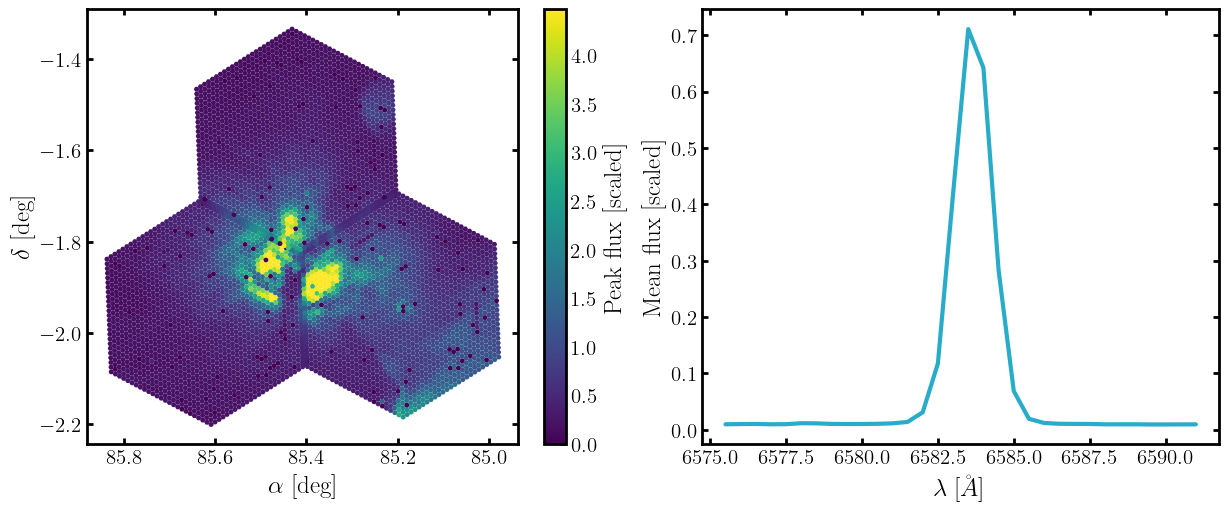

In [ ]:
# Quick look: spatial coverage and mean spectrum
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), layout="compressed")

peak_flux = fd.flux.max(axis=0)
vmax = np.nanpercentile(peak_flux, 99)
sc = ax1.scatter(
    fd.predict_α(fd.α),
    fd.predict_δ(fd.δ),
    c=peak_flux,
    s=5,
    cmap="viridis",
    marker="H",
    vmax=vmax,
)
ax1.set_xlabel(r"$\alpha$ [deg]")
ax1.set_ylabel(r"$\delta$ [deg]")
ax1.set_xlim(ax1.get_xlim()[::-1])
ax1.set_aspect("equal")
fig.colorbar(sc, ax=ax1, label="Peak flux [scaled]")

ax2.plot(fd.λ, fd.flux.mean(axis=1))
ax2.set_xlabel(r"$\lambda$ [$\AA$]")
ax2.set_ylabel("Mean flux [scaled]")
plt.show()

## Build the model

The model has three spatial fields represented by Gaussian Processes:
- **Amplitude** (`A`): integrated line flux at each position (constrained positive)
- **Velocity** (`v`): line-of-sight radial velocity, corrected for barycentric motion and bulk systemic velocity (unconstrained)
- **Velocity dispersion** (`vσ`): instrument-corrected line broadening (constrained positive)

Plus nuisance components: a per-spaxel continuum offset, per-tile flux calibration, and per-IFU wavelength calibration.

Each GP uses a Matérn-3/2 kernel with two hyperparameters: a **length scale** (spatial correlation distance) and a **variance** (amplitude of the GP prior). These are fixed at sensible values throughout the fit — we only optimise the GP coefficients, not the kernel hyperparameters. The length scale of 124 arcsec was chosen in Hilder+2025; the variance is set to 1 for the amplitude and velocity fields and 10 for the broadening field. Note that fixing the hyperparameters specifies the GP *prior*, not the result — the posterior (which we approximate via MAP) can have different effective correlation lengths and amplitudes depending on the data. Internally, the GPs are approximated via a truncated Fourier series — `N_MODES` just needs to be large enough for an accurate approximation (401×401 is more than sufficient here).

In [26]:
# Kernel length scale: 124 arcsec converted to the normalised model domain
ls_model_domain = fd.arcsec_to_model_domain(124)
print(f"Length scale: 124 arcsec → {ls_model_domain:.4f} in model domain")

# Kernel setup — hyperparameters stay fixed throughout optimisation
ls_kwargs = dict(initial=ls_model_domain, lower=1e-2, upper=10.0, fixed=True)
var_kwargs = dict(initial=1.0, lower=1e-5, upper=1e2, fixed=True)

A_kernel = Matern32(
    length_scale=ConstrainedParameter(**ls_kwargs),
    variance=ConstrainedParameter(**var_kwargs),
)
v_kernel = Matern32(
    length_scale=ConstrainedParameter(**ls_kwargs),
    variance=ConstrainedParameter(**var_kwargs),
)
vσ_kernel = Matern32(
    length_scale=ConstrainedParameter(**ls_kwargs),
    variance=ConstrainedParameter(
        **(var_kwargs | {"initial": 10.0})
    ),  # higher variance for broadening
)

# LSF width at the line centre (measured, not fitted)
i_λ0 = np.argmin(np.abs(fd.λ - CFG.lambda_centre))

# Build the model
my_model = build_model(
    LVMModelSingle,
    n_tiles=len(np.unique(fd.tile_idx)),
    n_spaxels=len(fd.spaxel_idx),
    n_modes=N_MODES,
    μ=Known(CFG.lambda_centre),
    A_kernel=A_kernel,
    v_kernel=v_kernel,
    vσ_kernel=vσ_kernel,
    σ_lsf=Known(fd.lsf_σ[i_λ0, :]),
    v_bary=Known(fd.v_bary),
    v_syst=Parameter(CFG.v_syst_init),  # initial guess for bulk systemic velocity
    C_v_cal=Parameter(jnp.array([0.0, 0.0])),
)

print(f"Model built with {N_MODES[0]}×{N_MODES[1]} Fourier modes")

Length scale: 124 arcsec → 0.2448 in model domain
Model built with 401×401 Fourier modes


### Inspecting the model

`spectracles` models are JAX pytrees. You can visualise the structure with `print_model_tree()` and `plot_model_graph()`, and list the parameter paths (used for the schedule) with `get_parameter_paths()` and `get_parameter_summary()`.

In [27]:
my_model.print_model_tree()

model (LVMModelSingle)
├── line (EmissionLineVCal)
│   ├── μ (Known)
│   ├── A (PositiveGPField)
│   │   └── gp (FourierGP)
│   │       ├── coefficients (Parameter)
│   │       └── kernel (Matern32)
│   │           ├── length_scale (ConstrainedParameter)
│   │           └── variance (ConstrainedParameter)
│   ├── v (GPField)
│   │   └── gp (FourierGP)
│   │       ├── coefficients (Parameter)
│   │       └── kernel (Matern32)
│   │           ├── length_scale (ConstrainedParameter)
│   │           └── variance (ConstrainedParameter)
│   ├── vσ (PositiveGPField)
│   │   └── gp (FourierGP)
│   │       ├── coefficients (Parameter)
│   │       └── kernel (Matern32)
│   │           ├── length_scale (ConstrainedParameter)
│   │           └── variance (ConstrainedParameter)
│   ├── σ_lsf (PerSpaxel)
│   │   └── spaxel_values (Known)
│   ├── v_bary (PerSpaxel)
│   │   └── spaxel_values (Known)
│   ├── v_syst (Parameter)
│   └── v_cal (WaveCalVelocity)
│       ├── C_v_cal (Parameter)
│       └── 

In [28]:
my_model.get_parameter_summary()

                               Parameter Summary                                
┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Path                    ┃ Shape      ┃ Bounds         ┃ Status ┃ Shared from ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━┩
│ line.A.gp.coefficients  │ (401, 401) │ (-∞, ∞)        │  free  │ -           │
│ line.A.gp.kernel.lengt… │ (1,)       │ (0.01, 10.0)   │ fixed  │ -           │
│ line.A.gp.kernel.varia… │ (1,)       │ (1e-05, 100.0) │ fixed  │ -           │
│ line.v.gp.coefficients  │ (401, 401) │ (-∞, ∞)        │  free  │ -           │
│ line.v.gp.kernel.lengt… │ (1,)       │ (0.01, 10.0)   │ fixed  │ -           │
│ line.v.gp.kernel.varia… │ (1,)       │ (1e-05, 100.0) │ fixed  │ -           │
│ line.vσ.gp.coefficients │ (401, 401) │ (-∞, ∞)        │  free  │ -           │
│ line.vσ.gp.kernel.leng… │ (1,)       │ (0.01, 10.0)   │ fixed  │ -           │
│ line.vσ.gp.kernel.vari… │ 

Note that the free/fixed status will be updated during the optimisation according to the schedule. See below.

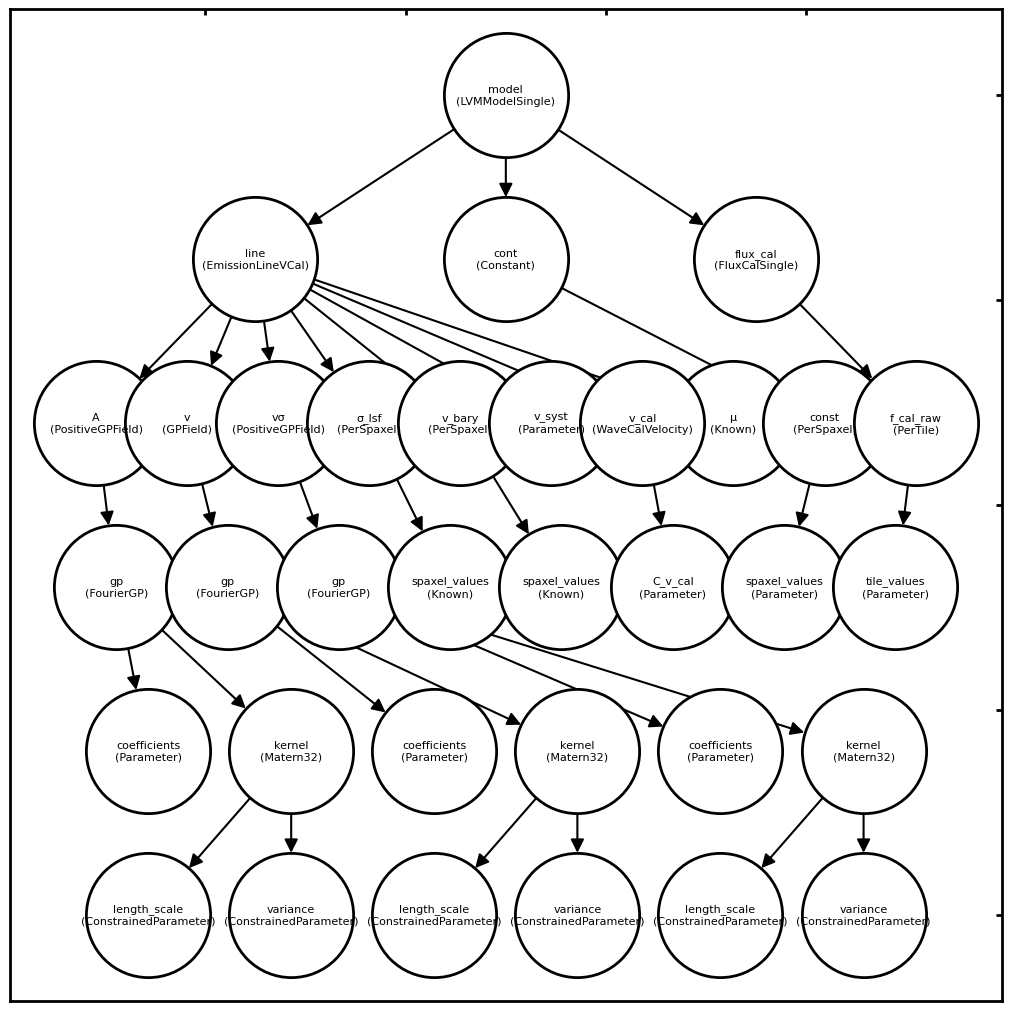

In [29]:
with plt.rc_context({"text.usetex": False}):
    my_model.plot_model_graph()

## Design the optimisation schedule

We use block coordinate descent: each phase frees a subset of parameters while keeping the rest fixed. This avoids poor local minima that arise from optimising everything at once.

The schedule is defined declaratively using `ParamSpec` objects:
- `free_in(0, 3, 4)` means the parameter is free (optimised) in phases 0, 3, and 4
- `init_normal(0)` means the parameter is initialised to random normal values at the start of phase 0
- These can be combined with `|`: `init_normal(0) | free_in(0, 3, 4)`

In [ ]:
N_STEPS = 2000
LR = 0.01

# (n_steps, learning_rate) for each phase
# Two passes of A → v → vσ: first with random init, second to polish
phases = [
    (N_STEPS, LR),  # 0: amplitude (init random)
    (N_STEPS, LR),  # 1: velocity (init random)
    (N_STEPS, LR),  # 2: broadening (init random)
    (N_STEPS, LR),  # 3: amplitude (polish)
    (N_STEPS, LR),  # 4: velocity (polish)
    (N_STEPS, LR),  # 5: broadening (polish)
]

# Which parameters are free in which phases.
# - v_cal is free alongside both A and v phases, since wavelength calibration
#   errors shift the line centre and affect both amplitude and velocity fits.
# - Continuum offsets and flux calibration are only free in amplitude phases,
#   since they scale the flux but don't affect the line position or width.
# - Kernel hyperparameters are never freed — they stay at their initial values. See Hilder+2026 for discussion.
params = {
    # GP coefficients
    "line.A.gp.coefficients": init_normal(0) | free_in(0, 3),
    "line.v.gp.coefficients": init_normal(1) | free_in(1, 4),
    "line.vσ.gp.coefficients": init_normal(2) | free_in(2, 5),
    # Global parameters
    "line.v_syst": free_in(0, 3),
    "line.v_cal.C_v_cal": free_in(0, 1, 3, 4),
    # Nuisances
    "cont.const.spaxel_values": free_in(0, 3),
    "flux_cal.f_cal_raw.tile_values": free_in(0, 3),
}

schedule = build_schedule(
    my_model,
    neg_ln_posterior,
    phases=phases,
    params=params,
    key=jr.key(42),
)

print(f"Schedule: {len(phases)} phases, {sum(p[0] for p in phases)} max steps")

Schedule: 6 phases, 12000 max steps


## Run the optimisation

In [31]:
schedule.run_all(
    λ=fd.λ,
    xy_data=fd.αδ_data,
    data=fd.flux,
    u_data=fd.u_flux,
    mask=fd.mask,
)

Optimising:   0%|          | 0/2000 [00:00<?, ?step/s]2026-03-15 15:43:11.584073: E external/xla/xla/backends/cpu/runtime/custom_call_thunk.cc:209] Custom call API version `API_VERSION_STATUS_RETURNING` is not supported by XLA:CPU. Prefer https://docs.jax.dev/en/latest/ffi.html. It will be fully removed in November 2025. Custom call target: nufft2d2
2026-03-15 15:43:11.584212: E external/xla/xla/backends/cpu/runtime/custom_call_thunk.cc:209] Custom call API version `API_VERSION_STATUS_RETURNING` is not supported by XLA:CPU. Prefer https://docs.jax.dev/en/latest/ffi.html. It will be fully removed in November 2025. Custom call target: nufft2d2
2026-03-15 15:43:11.584318: E external/xla/xla/backends/cpu/runtime/custom_call_thunk.cc:209] Custom call API version `API_VERSION_STATUS_RETURNING` is not supported by XLA:CPU. Prefer https://docs.jax.dev/en/latest/ffi.html. It will be fully removed in November 2025. Custom call target: nufft2d2
2026-03-15 15:43:11.614361: E external/xla/xla/backe

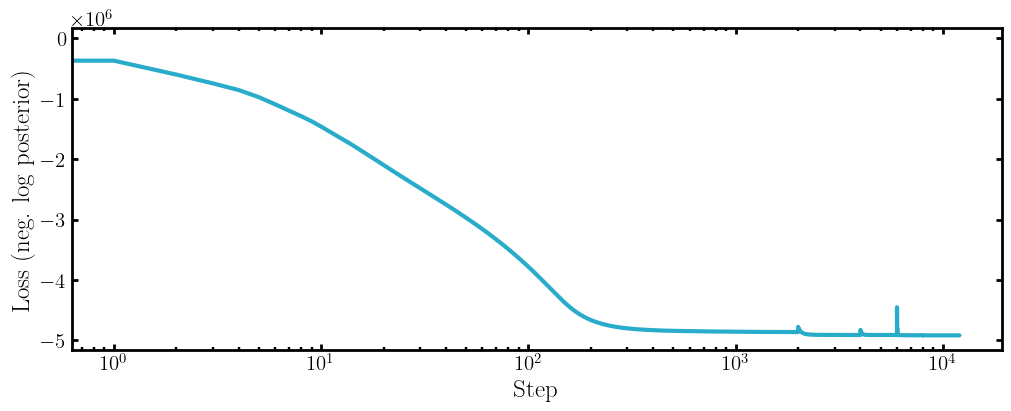

In [32]:
# Loss curve (loss = negative log posterior)
fig, ax = plt.subplots(figsize=(10, 4), layout="compressed")
ax.plot(schedule.loss_history)
ax.set_xscale("log")
ax.set_xlabel("Step")
ax.set_ylabel("Loss (neg. log posterior)")
plt.show()

## Save the fitted model

The model is saved so it can be loaded in the plotting notebook without re-running the fit.

In [33]:
MODEL_DIR.mkdir(parents=True, exist_ok=True)
save_model(schedule.model_history[-1], MODEL_PATH, overwrite=True)
print(f"Saved to {MODEL_PATH}")

Saved to models/nii.model
